In [1]:
!pip install kagglehub
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn pillow

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
pneumonia_path = "/kaggle/input/chest-xray-pneumonia"
skin_path = "/kaggle/input/skin-cancer-dataset"
lung_path = "/kaggle/input/the-iqothnccd-lung-cancer-dataset"

print("Pneumonia dataset:", pneumonia_path)
print("Skin cancer dataset:", skin_path)
print("Lung cancer dataset:", lung_path)

Pneumonia dataset: /kaggle/input/chest-xray-pneumonia
Skin cancer dataset: /kaggle/input/skin-cancer-dataset
Lung cancer dataset: /kaggle/input/the-iqothnccd-lung-cancer-dataset


In [4]:
import kagglehub

# Download datasets
pneumonia_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
skin_path = kagglehub.dataset_download("farjanakabirsamanta/skin-cancer-dataset")
lung_path = kagglehub.dataset_download("hamdallak/the-iqothnccd-lung-cancer-dataset")

print("Pneumonia dataset path:", pneumonia_path)
print("Skin cancer dataset path:", skin_path)
print("Lung cancer dataset path:", lung_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Using Colab cache for faster access to the 'skin-cancer-dataset' dataset.
Using Colab cache for faster access to the 'the-iqothnccd-lung-cancer-dataset' dataset.
Pneumonia dataset path: /kaggle/input/chest-xray-pneumonia
Skin cancer dataset path: /kaggle/input/skin-cancer-dataset
Lung cancer dataset path: /kaggle/input/the-iqothnccd-lung-cancer-dataset


In [5]:
import os

print("Pneumonia dataset folders:")
print(os.listdir(pneumonia_path))

print("\nSkin cancer dataset folders:")
print(os.listdir(skin_path))

print("\nLung cancer dataset folders:")
print(os.listdir(lung_path))

Pneumonia dataset folders:
['chest_xray']

Skin cancer dataset folders:
['Skin Cancer', 'HAM10000_metadata.csv']

Lung cancer dataset folders:
['The IQ-OTHNCCD lung cancer dataset']


In [6]:
print(os.listdir(pneumonia_path + "/chest_xray"))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [7]:
print("Train folders:", os.listdir(pneumonia_path + "/chest_xray/train"))

Train folders: ['PNEUMONIA', 'NORMAL']


In [8]:
import os

normal_count = len(os.listdir(pneumonia_path + "/chest_xray/train/NORMAL"))
pneumonia_count = len(os.listdir(pneumonia_path + "/chest_xray/train/PNEUMONIA"))

print("Normal images:", normal_count)
print("Pneumonia images:", pneumonia_count)

Normal images: 1341
Pneumonia images: 3875


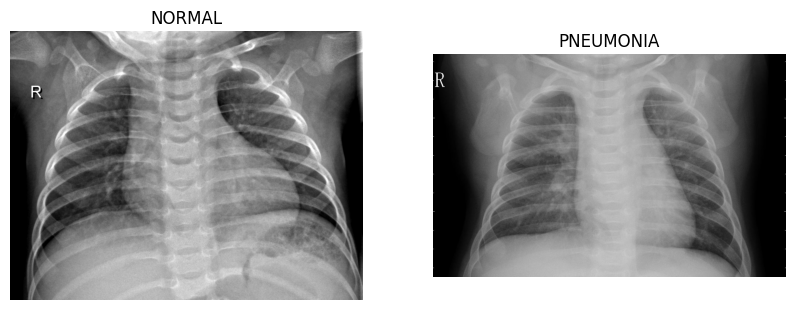

In [9]:
import cv2
import matplotlib.pyplot as plt
import random
import os

normal_dir = pneumonia_path + "/chest_xray/train/NORMAL"
pneumonia_dir = pneumonia_path + "/chest_xray/train/PNEUMONIA"

normal_img = random.choice(os.listdir(normal_dir))
pneumonia_img = random.choice(os.listdir(pneumonia_dir))

normal_path = os.path.join(normal_dir, normal_img)
pneumonia_path_img = os.path.join(pneumonia_dir, pneumonia_img)

normal = cv2.imread(normal_path)
pneumonia = cv2.imread(pneumonia_path_img)

normal = cv2.cvtColor(normal, cv2.COLOR_BGR2RGB)
pneumonia = cv2.cvtColor(pneumonia, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(normal)
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia)
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = pneumonia_path + "/chest_xray/train"
test_dir = pneumonia_path + "/chest_xray/test"

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
for layer in base_model.layers:
    layer.trainable = False

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.7390 - loss: 0.5862 - val_accuracy: 0.7430 - val_loss: 0.5698
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 821ms/step - accuracy: 0.7429 - loss: 0.5837 - val_accuracy: 0.7430 - val_loss: 0.5704
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 862ms/step - accuracy: 0.7429 - loss: 0.5845 - val_accuracy: 0.7430 - val_loss: 0.5701
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 851ms/step - accuracy: 0.7429 - loss: 0.5809 - val_accuracy: 0.7430 - val_loss: 0.5760
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 112s 856ms/step - accuracy: 0.7429 - loss: 0.5833 - val_accuracy: 0.7430 - val_loss: 0.5727
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 868ms/step - accuracy: 0.7429 - loss: 0.5783 - val_accuracy: 0.7430 - val_loss: 0.5715
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 864ms/step - accuracy: 0.7429 - loss: 0.5766 - val_accuracy: 0.7430 - val_loss: 0.5707
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 836ms/step - accuracy: 0.7429 - lo

In [17]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.7426 - loss: 0.5787 - val_accuracy: 0.7430 - val_loss: 0.5713
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 799ms/step - accuracy: 0.7429 - loss: 0.5739 - val_accuracy: 0.7430 - val_loss: 0.5702
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 823ms/step - accuracy: 0.7429 - loss: 0.5777 - val_accuracy: 0.7430 - val_loss: 0.5692
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 830ms/step - accuracy: 0.7429 - loss: 0.5731 - val_accuracy: 0.7430 - val_loss: 0.5691
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 836ms/step - accuracy: 0.7429 - loss: 0.5735 - val_accuracy: 0.7430 - val_loss: 0.5685


In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [21]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 147s 934ms/step - accuracy: 0.6216 - loss: 0.7156 - val_accuracy: 0.7430 - val_loss: 0.6505
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 821ms/step - accuracy: 0.5878 - loss: 0.6965 - val_accuracy: 0.7430 - val_loss: 0.6736
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 830ms/step - accuracy: 0.5545 - loss: 0.6959 - val_accuracy: 0.7430 - val_loss: 0.6642
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.5217 - loss: 0.6970 - val_accuracy: 0.7430 - val_loss: 0.6821
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 796ms/step - accuracy: 0.5924 - loss: 0.6943 - val_accuracy: 0.2570 - val_loss: 0.6956


In [22]:
import numpy as np

test_data.reset()

pred_probs = model.predict(test_data)
predictions = (pred_probs > 0.5).astype(int)

true_labels = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step


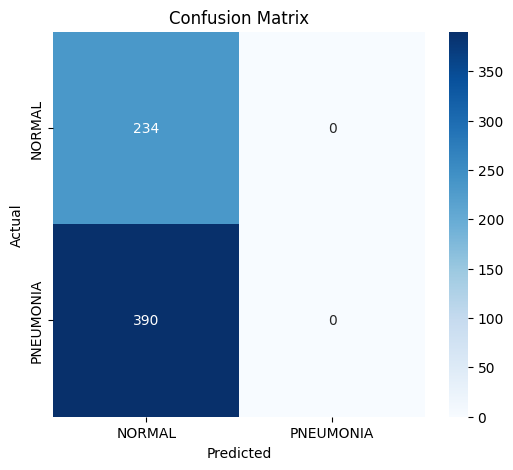

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predictions,
    target_names=['NORMAL','PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.38      1.00      0.55       234
   PNEUMONIA       0.00      0.00      0.00       390

    accuracy                           0.38       624
   macro avg       0.19      0.50      0.27       624
weighted avg       0.14      0.38      0.20       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(true_labels, predictions))

Test Accuracy: 0.375


In [26]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [27]:
base_model_vgg = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

print("VGG16 loaded")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded


In [28]:
x = base_model_vgg.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

vgg_model = Model(inputs=base_model_vgg.input, outputs=output)

print("VGG16 model ready")

VGG16 model ready


In [29]:
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled")

Model compiled


In [30]:
vgg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 14,846,273 (56.63 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
for layer in base_model_vgg.layers:
    layer.trainable = False

In [32]:
x = base_model_vgg.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

vgg_model = Model(inputs=base_model_vgg.input, outputs=output)

In [33]:
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
vgg_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [35]:
history_vgg = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.8366 - loss: 0.3634 - val_accuracy: 0.9156 - val_loss: 0.2351
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 919ms/step - accuracy: 0.9065 - loss: 0.2276 - val_accuracy: 0.9233 - val_loss: 0.2000
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 898ms/step - accuracy: 0.9250 - loss: 0.1922 - val_accuracy: 0.9358 - val_loss: 0.1704
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 880ms/step - accuracy: 0.9334 - loss: 0.1766 - val_accuracy: 0.9386 - val_loss: 0.1688
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 862ms/step - accuracy: 0.9343 - loss: 0.1715 - val_accuracy: 0.9396 - val_loss: 0.1642
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 867ms/step - accuracy: 0.9382 - loss: 0.1583 - val_accuracy: 0.9501 - val_loss: 0.1381
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 874ms/step - accuracy: 0.9425 - loss: 0.1543 - val_accuracy: 0.9530 - val_loss: 0.1363
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 878ms/step - accuracy: 0.9406 - lo

In [40]:
test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [41]:
test_data.reset()

pred_probs = vgg_model.predict(test_data)
predictions = (pred_probs > 0.5).astype(int)

true_labels = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 625ms/step


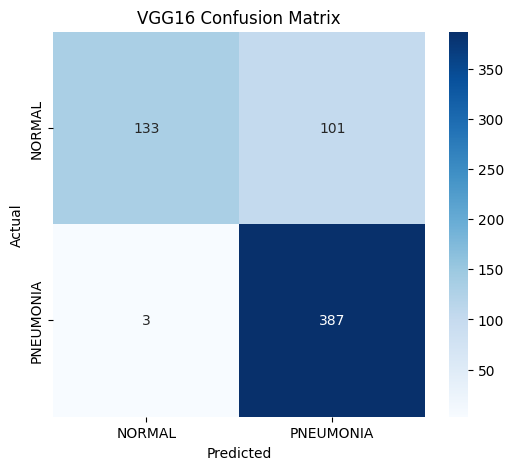

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL","PNEUMONIA"],
            yticklabels=["NORMAL","PNEUMONIA"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")
plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predictions,
    target_names=["NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.98      0.57      0.72       234
   PNEUMONIA       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624



In [44]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_resnet.layers:
    layer.trainable = False

x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=base_model_resnet.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [45]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [46]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 905ms/step - accuracy: 0.7230 - loss: 0.5992 - val_accuracy: 0.7430 - val_loss: 0.5328
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 806ms/step - accuracy: 0.7513 - loss: 0.5189 - val_accuracy: 0.7478 - val_loss: 0.4796
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 800ms/step - accuracy: 0.7611 - loss: 0.4801 - val_accuracy: 0.7536 - val_loss: 0.4521
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 801ms/step - accuracy: 0.7731 - loss: 0.4429 - val_accuracy: 0.7967 - val_loss: 0.4287
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 797ms/step - accuracy: 0.7956 - loss: 0.4156 - val_accuracy: 0.7872 - val_loss: 0.4056


In [47]:
test_loss, test_accuracy = resnet_model.evaluate(test_data)

print("ResNet50 Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 744ms/step - accuracy: 0.6571 - loss: 0.5846
ResNet50 Test Accuracy: 0.6570512652397156


In [48]:
test_data.reset()

pred_probs = resnet_model.predict(test_data)
predictions = (pred_probs > 0.5).astype(int)

true_labels = test_data.classes

from sklearn.metrics import classification_report
print(classification_report(true_labels, predictions, target_names=["NORMAL","PNEUMONIA"]))

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 729ms/step
              precision    recall  f1-score   support

      NORMAL       0.69      0.18      0.28       234
   PNEUMONIA       0.66      0.95      0.78       390

    accuracy                           0.66       624
   macro avg       0.68      0.56      0.53       624
weighted avg       0.67      0.66      0.59       624



(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

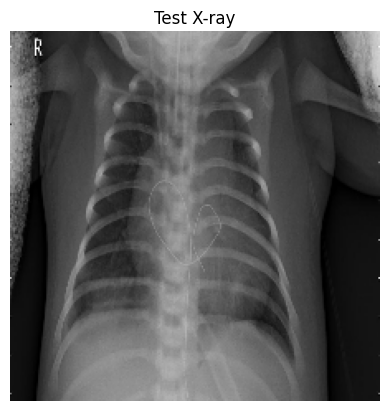

In [49]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
import os

pneumonia_dir = pneumonia_path + "/chest_xray/test/PNEUMONIA"

img_name = random.choice(os.listdir(pneumonia_dir))
img_path = os.path.join(pneumonia_dir, img_name)

img = cv2.imread(img_path)
img = cv2.resize(img,(224,224))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Test X-ray")
plt.axis("off")

In [50]:
import numpy as np

img_array = img_rgb / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = vgg_model.predict(img_array)

print("Prediction probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction probability: 0.64610326
Prediction: PNEUMONIA


In [52]:
import tensorflow as tf
import numpy as np
import cv2

last_conv_layer = vgg_model.get_layer("block5_conv3")

grad_model = tf.keras.models.Model(
    [vgg_model.inputs],
    [last_conv_layer.output, vgg_model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap,0) / np.max(heatmap)
heatmap = heatmap

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

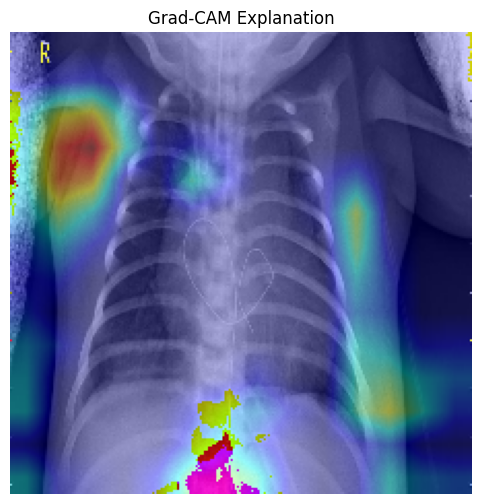

In [53]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Explanation")
plt.axis("off")

In [54]:
confidence = float(prediction[0][0])

if confidence > 0.5:
    diagnosis = "PNEUMONIA"
    explanation = """
The AI model detected abnormal opacity patterns
in the lung region. These highlighted regions
may indicate infection or fluid accumulation
commonly associated with pneumonia.
"""
else:
    diagnosis = "NORMAL"
    explanation = """
The lung X-ray appears clear with no significant
opacity or abnormal patterns detected.
"""

print("Diagnosis:", diagnosis)
print("Confidence:", round(confidence*100,2), "%")
print("\nExplanation:", explanation)

Diagnosis: PNEUMONIA
Confidence: 64.61 %

Explanation: 
The AI model detected abnormal opacity patterns
in the lung region. These highlighted regions
may indicate infection or fluid accumulation
commonly associated with pneumonia.



In [ ]:
vgg_model.save("pneumonia_model.pkl")

In [ ]:
import os

save_path = r"d:\Projects\Hackathon2.0\Watumall_HVAI_03\explainable-med\backend\ml\models\pneumonia_model.h5"

# Use 'vgg_model' or whatever your trained model variable is called
vgg_model.save(save_path)
print(f"✅ Saved to: {save_path}")